# VedaVision — Single-Leaf Full Pipeline Walkthrough
### Module 3: Compound Leaf Analysis — Species-ID + Health Assessment

Runs **one physical leaf** (a top-view image, and optionally a matching
bottom-view image) through every stage of both branches, saving each
intermediate result as a figure under `figures_out/` for direct use in
Chapter 6 (Implementation) screenshots.

**Before running:** set `TOP_IMAGE_PATH` / `BOTTOM_IMAGE_PATH` /
`SPECIES_NAME` below to a real image from your dataset. Run from the
`module_3/` project root (same convention as `model_training.py`), e.g.:

```
D:\Python313\python.exe -m jupyter notebook
```

This notebook calls the SAME functions the real training pipeline uses
(`preprocessing.species_id.pipeline.run_pipeline`,
`preprocessing.health.pipeline`, `feature_extraction.health.*`) — nothing
here is a reimplementation, so every figure reflects exactly what the
model actually sees.


In [52]:
import os
import sys

# Idempotent: only chdir up once, even if this cell is re-run (e.g. Restart & Run All
# vs. re-running just this cell mid-session) — walking up ".." repeatedly on reruns
# would otherwise silently break every relative path below after the 2nd run.
# Detects "already at module_3/ root" by checking for a folder that only exists there.
if not os.path.isdir("preprocessing"):
    os.chdir("..")
assert os.path.isdir("preprocessing") and os.path.isdir("models"), (
    f"Not at module_3/ root (cwd={os.getcwd()}). This notebook expects to live at "
    f"module_3/notebooks/ and run with that as the only ancestor between it and "
    f"module_3/ itself — adjust the chdir logic above if your layout differs."
)
sys.path.insert(0, os.getcwd())

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("figures_out")
FIG_DIR.mkdir(exist_ok=True)

def bgr2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def save_fig(fig, name, dpi=200):
    """Save a matplotlib figure to figures_out/<name>.png, ready to insert into the dissertation."""
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"[saved] {path}")

def show_grid(images, titles, ncols=3, figsize_per=(4,4), cmap=None, suptitle=None, save_as=None):
    n = len(images)
    nrows = int(np.ceil(n/ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per[0]*ncols, figsize_per[1]*nrows))
    axes = np.array(axes).reshape(-1)
    for ax, img, title in zip(axes, images, titles):
        if img.ndim == 2:
            ax.imshow(img, cmap=cmap or "gray")
        else:
            ax.imshow(img)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=13)
    fig.tight_layout()
    if save_as:
        save_fig(fig, save_as)
    plt.show()
    return fig


## 0. Load the leaf

Set these three paths/labels to a real sample before running.

[saved] figures_out\00_raw_leaf_input.png


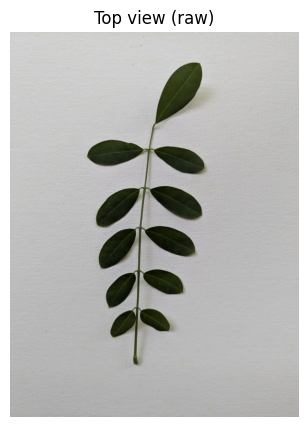

In [71]:
TOP_IMAGE_PATH    = "dataset/raw/nil_awariya/top/PXL_20260713_052632835.jpg"      # <-- EDIT
BOTTOM_IMAGE_PATH  = "None"    # <-- EDIT (health branch only; set None to skip)
SPECIES_NAME       = "Nil Awariya"                                              # <-- EDIT

img_top_raw = cv2.imread(TOP_IMAGE_PATH)
assert img_top_raw is not None, f"Could not read {TOP_IMAGE_PATH} — check the path."
img_bottom_raw = cv2.imread(BOTTOM_IMAGE_PATH) if BOTTOM_IMAGE_PATH else None

fig, ax = plt.subplots(1, 2 if img_bottom_raw is not None else 1, figsize=(10,5))
if img_bottom_raw is not None:
    ax[0].imshow(bgr2rgb(img_top_raw)); ax[0].set_title("Top view (raw)"); ax[0].axis("off")
    ax[1].imshow(bgr2rgb(img_bottom_raw)); ax[1].set_title("Bottom view (raw)"); ax[1].axis("off")
else:
    ax.imshow(bgr2rgb(img_top_raw)); ax.set_title("Top view (raw)"); ax.axis("off")
save_fig(fig, "00_raw_leaf_input")
plt.show()


---
# PART A — Species Identification Branch

Uses `preprocessing.species_id.pipeline.run_pipeline`, which returns an
`info` dict already carrying every intermediate array (resize, mask,
masked image, enhanced image, vein skeleton) exactly as used in training.


In [72]:
from preprocessing.species_id.pipeline import run_pipeline

feats_species, info = run_pipeline(
    img_path=TOP_IMAGE_PATH,
    species=SPECIES_NAME,
    view_side="top",
)
print("QC passed:", info["qc_passed"], "| reason:", info.get("qc_reason"))
print("Mask choice:", info.get("mask_choice"))


QC passed: True | reason: 
Mask choice: tight


### A.1 — Preprocessing pipeline: resize → mask → masked leaf → enhanced

[saved] figures_out\A1_species_preprocessing_pipeline.png


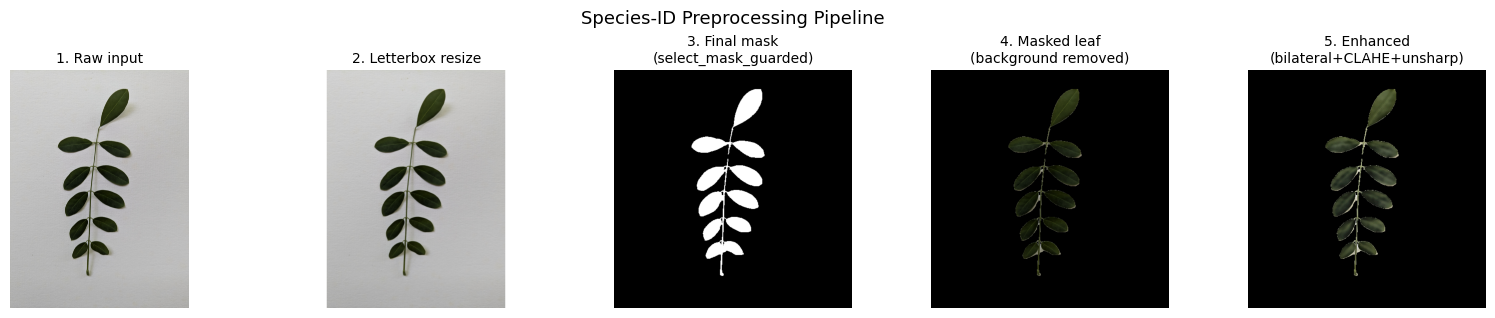

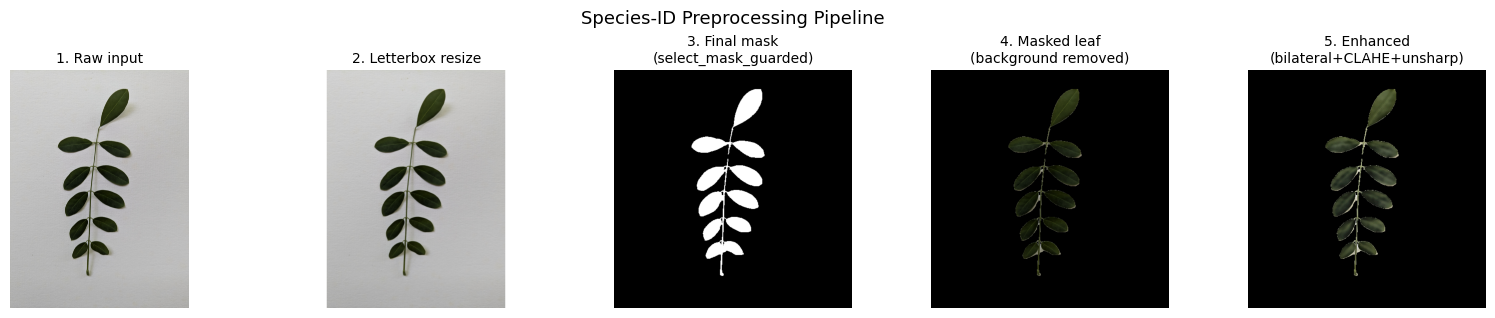

In [73]:
show_grid(
    [bgr2rgb(info["img_orig"]), bgr2rgb(info["img_resized"]),
     info["mask_final"], bgr2rgb(info["img_masked"]), bgr2rgb(info["img_sharp"])],
    ["1. Raw input", "2. Letterbox resize", "3. Final mask\n(select_mask_guarded)",
     "4. Masked leaf\n(background removed)", "5. Enhanced\n(bilateral+CLAHE+unsharp)"],
    ncols=5, figsize_per=(3.2,3.2),
    suptitle="Species-ID Preprocessing Pipeline",
    save_as="A1_species_preprocessing_pipeline",
)


### A.2 — Augmentation pipeline (training-time variants)

Matches Chapter 6's "Augmentation Pipeline" figure. **Uses the actual
production function** `augment_resized_with_mask_and_original()` — NOT
`augment_raw()`. The batch processor masks once on the clean resized
image, then warps image+mask together for geometry; photometric
transforms apply to the image only (see `species_id/batch_processor.py`
header comment for why re-masking each photometric variant was dropped —
RandomShadow was failing masking.py's colour gates on some leaflets).

[saved] figures_out\A2_augmentation_pipeline.png


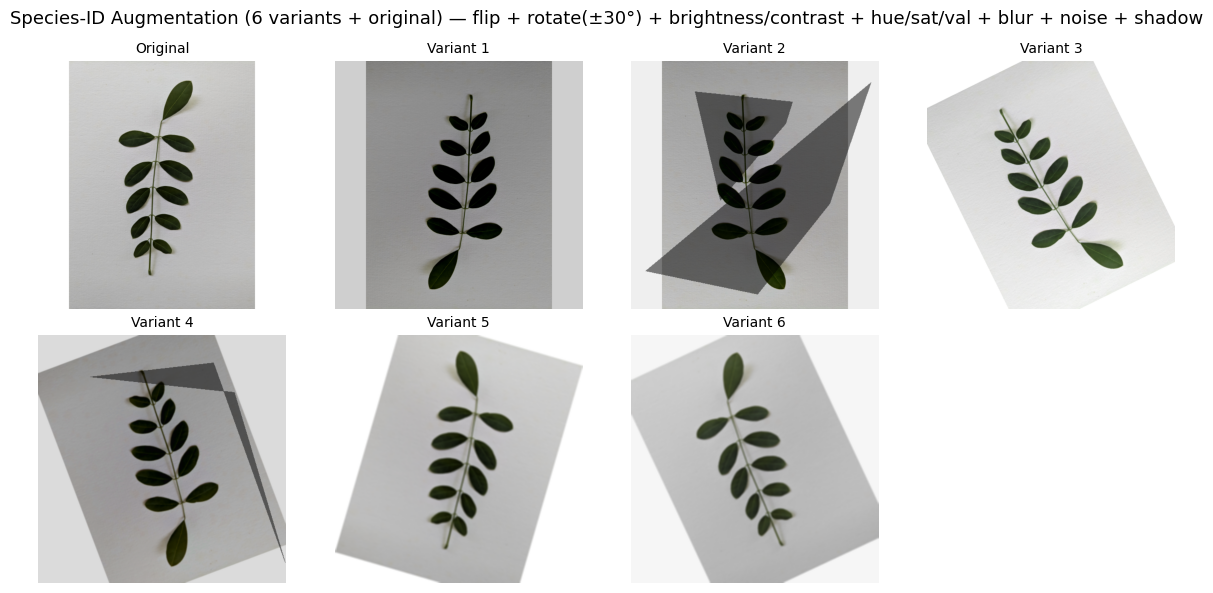

[saved] figures_out\A2b_augmentation_masks.png


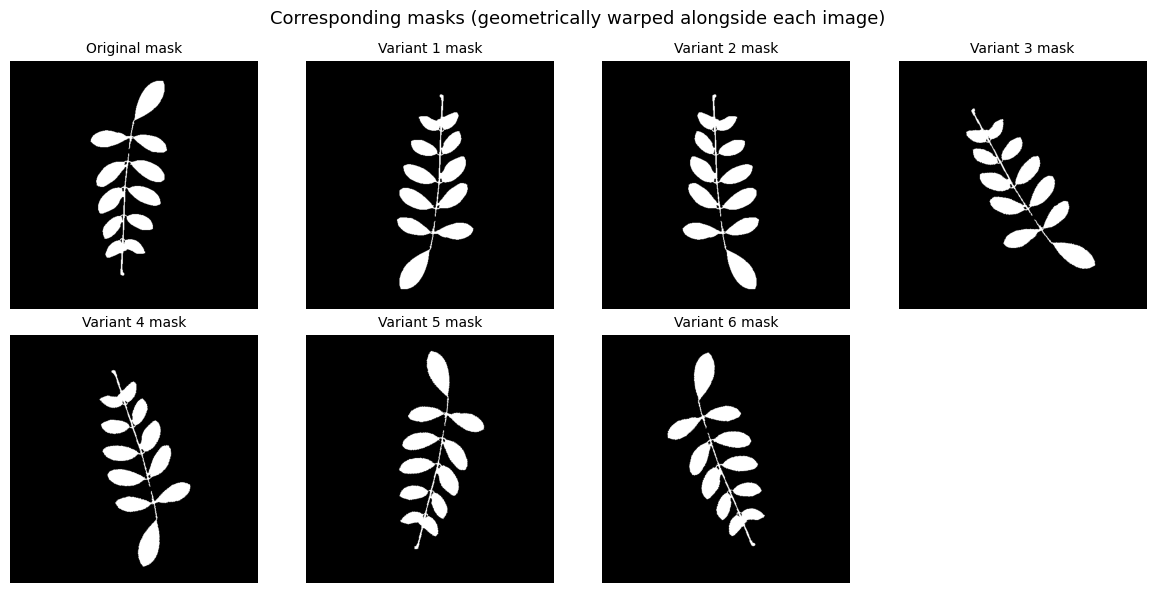

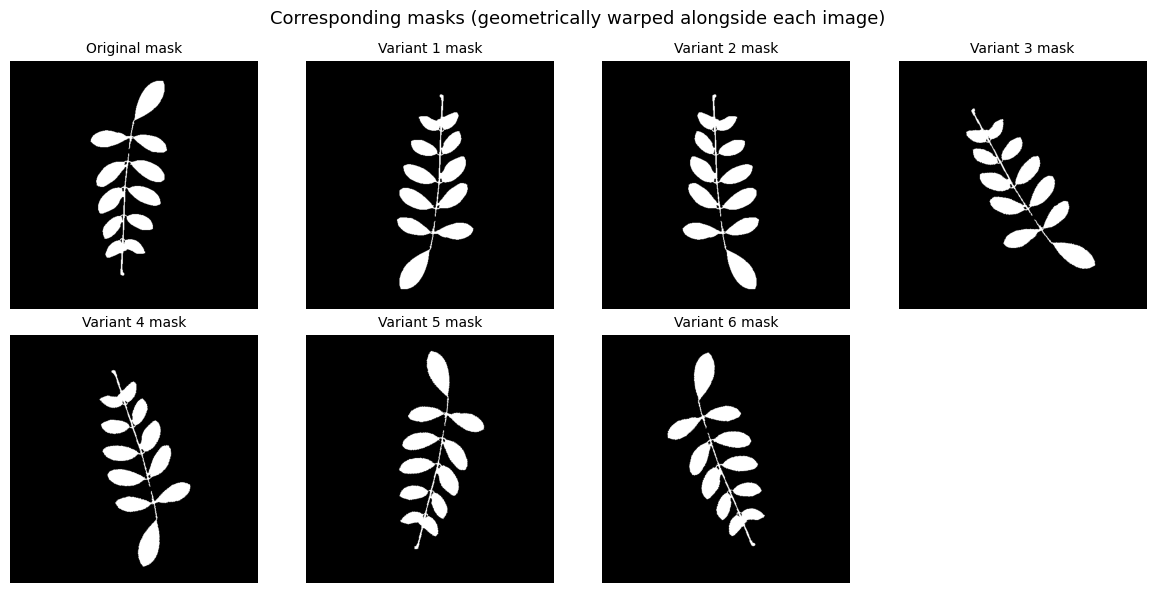

In [74]:
from preprocessing.shared.augmentation import augment_resized_with_mask_and_original, N_AUGMENTATIONS

pairs = augment_resized_with_mask_and_original(info["img_resized"], info["mask_final"], n=N_AUGMENTATIONS)
# pairs[0] = (original image, original mask); pairs[1..N] = augmented (image, geometrically-warped mask)

show_grid(
    [bgr2rgb(img) for img, _ in pairs],
    ["Original"] + [f"Variant {i+1}" for i in range(N_AUGMENTATIONS)],
    ncols=4, figsize_per=(3,3),
    suptitle=f"Species-ID Augmentation ({N_AUGMENTATIONS} variants + original) — "
             f"flip + rotate(\u00b130\u00b0) + brightness/contrast + hue/sat/val + blur + noise + shadow",
    save_as="A2_augmentation_pipeline",
)

# masks warp together with the geometric transforms — worth showing explicitly
show_grid(
    [mask for _, mask in pairs],
    ["Original mask"] + [f"Variant {i+1} mask" for i in range(N_AUGMENTATIONS)],
    ncols=4, figsize_per=(3,3), cmap="gray",
    suptitle="Corresponding masks (geometrically warped alongside each image)",
    save_as="A2b_augmentation_masks",
)


### A.3 — Shape features

Computed from `mask_final` — aspect ratio, circularity, solidity, convexity, compactness, elongation (+ Hu moments).

[saved] figures_out\A3_shape_features.png


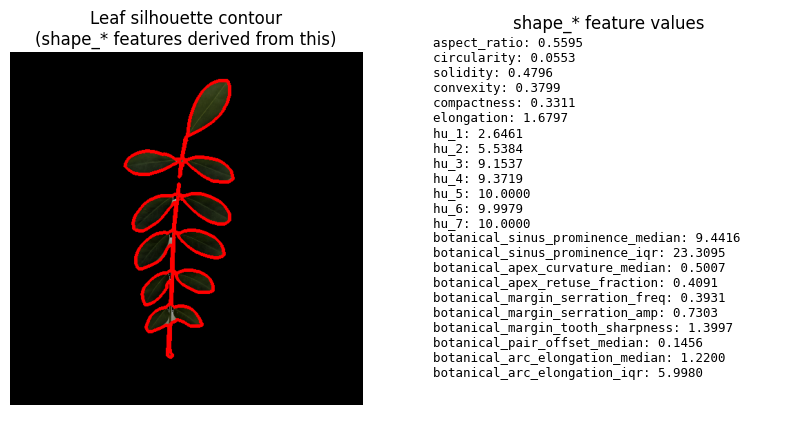

In [75]:
from feature_extraction.species_id.shape import extract_shape_features

shape_f = extract_shape_features(info["mask_final"])
contour, _ = cv2.findContours(info["mask_final"].astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
overlay = bgr2rgb(info["img_masked"]).copy()
cv2.drawContours(overlay, contour, -1, (255,0,0), 3)

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(overlay); ax[0].set_title("Leaf silhouette contour\n(shape_* features derived from this)"); ax[0].axis("off")
ax[1].axis("off")
ax[1].text(0, 1, "\n".join(f"{k}: {v:.4f}" if isinstance(v,float) else f"{k}: {v}"
                             for k,v in shape_f.items()), fontsize=9, va="top", family="monospace")
ax[1].set_title("shape_* feature values")
save_fig(fig, "A3_shape_features")
plt.show()


### A.4 — Colour features

Robust (median/IQR) per-channel BGR/HSV/LAB statistics, computed on the **raw** resized image (pre-enhancement) within the mask.

[saved] figures_out\A4_colour_features.png


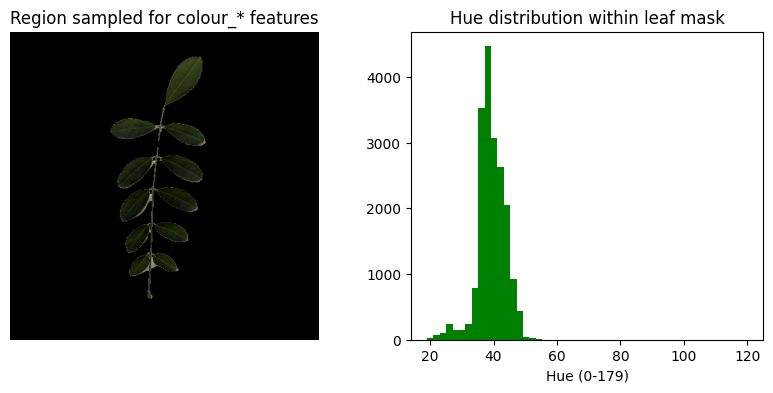

{'bgr_b_median': 16.0, 'bgr_b_iqr': 13.0, 'bgr_b_q25': 10.0, 'bgr_b_q75': 23.0, 'bgr_b_skew': 2.752, 'bgr_b_kurt': 8.0421, 'bgr_g_median': 38.0, 'bgr_g_iqr': 24.0, 'bgr_g_q25': 28.0, 'bgr_g_q75': 52.0} ...


In [76]:
from feature_extraction.species_id.colour import extract_colour_features

colour_f = extract_colour_features(info["img_resized"], info["mask_final"])

# simple visual: masked leaf pixels plotted in HSV hue histogram
leaf_pixels_hsv = cv2.cvtColor(info["img_resized"], cv2.COLOR_BGR2HSV)[info["mask_final"] > 0]
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].imshow(bgr2rgb(info["img_masked"])); ax[0].set_title("Region sampled for colour_* features"); ax[0].axis("off")
ax[1].hist(leaf_pixels_hsv[:,0], bins=50, color="green")
ax[1].set_title("Hue distribution within leaf mask")
ax[1].set_xlabel("Hue (0-179)")
save_fig(fig, "A4_colour_features")
plt.show()
print({k: round(v,4) if isinstance(v,float) else v for k,v in list(colour_f.items())[:10]}, "...")


### A.5 — Texture features (GLCM + LBP)

Computed on the **enhanced** image within the mask.

[saved] figures_out\A5_texture_features.png


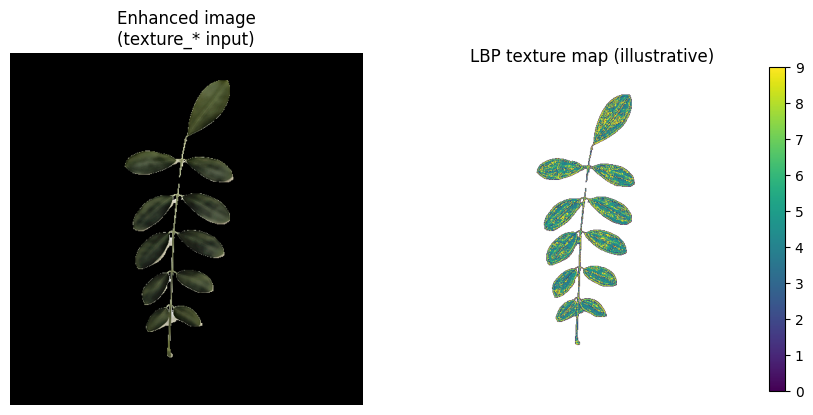

{'glcm_contrast_mean': 31.0279, 'glcm_contrast_std': 7.1638, 'glcm_homogeneity_mean': 0.8197, 'glcm_homogeneity_std': 0.0341, 'glcm_energy_mean': 0.7108, 'glcm_energy_std': 0.0121, 'glcm_correlation_mean': 0.4405, 'glcm_correlation_std': 0.1274, 'lbp_00': 0.0621, 'lbp_01': 0.0327, 'lbp_02': 0.0163, 'lbp_03': 0.0118, 'lbp_04': 0.0121, 'lbp_05': 0.0126, 'lbp_06': 0.0139, 'lbp_07': 0.0135, 'lbp_08': 0.0132, 'lbp_09': 0.0206, 'lbp_10': 0.031, 'lbp_11': 0.0528, 'lbp_12': 0.0763, 'lbp_13': 0.0628, 'lbp_14': 0.044, 'lbp_15': 0.033, 'lbp_16': 0.0234, 'lbp_17': 0.0147, 'lbp_18': 0.0133, 'lbp_19': 0.0125, 'lbp_20': 0.0105, 'lbp_21': 0.0089, 'lbp_22': 0.007, 'lbp_23': 0.0077, 'lbp_24': 0.0127, 'lbp_25': 0.3806, 'lbp_mean': 16.0637, 'lbp_std': 8.5632, 'botanical_local_contrast_variance': 600.5091}


In [77]:
from feature_extraction.species_id.texture import extract_texture_features
from skimage.feature import local_binary_pattern

texture_f = extract_texture_features(info["img_sharp"], info["mask_final"])

gray = cv2.cvtColor(info["img_sharp"], cv2.COLOR_BGR2GRAY)
lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
lbp_masked = np.where(info["mask_final"] > 0, lbp, np.nan)

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(bgr2rgb(info["img_sharp"])); ax[0].set_title("Enhanced image\n(texture_* input)"); ax[0].axis("off")
im = ax[1].imshow(lbp_masked, cmap="viridis")
ax[1].set_title("LBP texture map (illustrative)"); ax[1].axis("off")
fig.colorbar(im, ax=ax[1], fraction=0.046)
save_fig(fig, "A5_texture_features")
plt.show()
print({k: round(v,4) for k,v in texture_f.items()})


### A.6 — Vein extraction

ROI-crop-then-upscale pipeline; skeletonised vein network.

[saved] figures_out\A6_vein_extraction.png


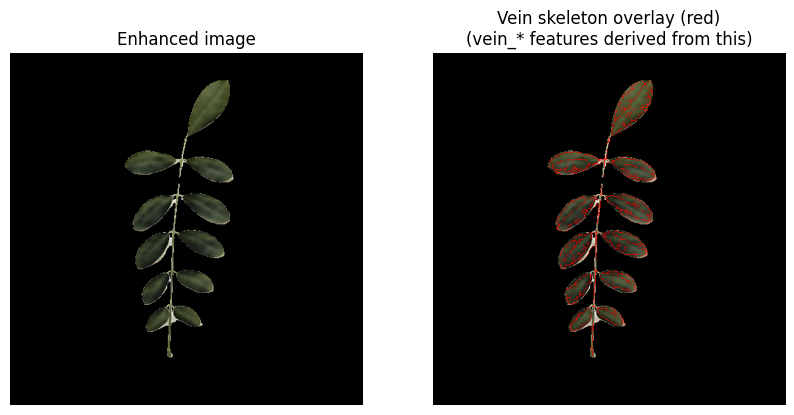

{'botanical_vein_density': 0.1381, 'botanical_vein_length_ratio': 1.6006, 'botanical_vein_branch_density': 0.0338, 'botanical_vein_end_point_density': 0.0278, 'vein_coverage_pct': 0.0723, 'vein_roi_scale': 1.2019, 'botanical_vein_spacing_period': 11.0, 'botanical_vein_prominence_contrast': 0.9033, 'botanical_vein_base_branch_angle': 30.0342, 'botanical_vein_base_branch_count': 24.0, 'botanical_vein_angle_median': 42.2499, 'botanical_vein_loop_fraction': 0.0792, 'botanical_tertiary_reticulation_density': 324.6706}


In [78]:
from feature_extraction.species_id.vein import extract_vein_features

vein_f, skel, _ = extract_vein_features(info["img_sharp"], info["mask_final"])
overlay = bgr2rgb(info["img_sharp"]).copy()
if skel is not None:
    ys, xs = np.where(skel > 0)
    overlay[ys, xs] = [255, 0, 0]

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(bgr2rgb(info["img_sharp"])); ax[0].set_title("Enhanced image"); ax[0].axis("off")
ax[1].imshow(overlay); ax[1].set_title("Vein skeleton overlay (red)\n(vein_* features derived from this)"); ax[1].axis("off")
save_fig(fig, "A6_vein_extraction")
plt.show()
print({k: round(v,4) if isinstance(v,float) else v for k,v in vein_f.items()})


---
# PART B — Health Assessment Branch

Mirrors `preprocessing/health/pipeline.py::run_health_pipeline`, but keeps
every intermediate array (instead of only the final flat feature row) for
figure generation. **No enhancement is ever applied on this branch** —
masked_raw only, per the hard architectural rule in project memory.


In [56]:
from preprocessing.shared.resize import letterbox_resize
from preprocessing.shared.masking import select_mask, qc_check

def run_health_pipeline_verbose(img_bgr_raw):
    """Same steps as run_health_pipeline(), but returns every intermediate for plotting."""
    resized, _ = letterbox_resize(img_bgr_raw)
    mask_final, mask_choice, diag = select_mask(resized)
    mask_before_holefill = diag.get("mask_before_holefill")
    rachis_mask = diag.get("rachis_mask")
    qc_ok, qc_reason = qc_check(diag)
    masked_raw = cv2.bitwise_and(resized, resized, mask=mask_final.astype(np.uint8))
    return {
        "resized": resized, "mask_final": mask_final, "mask_choice": mask_choice,
        "diag": diag, "mask_before_holefill": mask_before_holefill,
        "rachis_mask": rachis_mask, "masked_raw": masked_raw,
        "qc_ok": qc_ok, "qc_reason": qc_reason,
    }

h_top = run_health_pipeline_verbose(img_top_raw)
h_bottom = run_health_pipeline_verbose(img_bottom_raw) if img_bottom_raw is not None else None
print("Top QC:", h_top["qc_ok"], h_top["qc_reason"], "| mask_choice:", h_top["mask_choice"])


Top QC: True  | mask_choice: loose


### B.1 — Health masking (no enhancement)

[saved] figures_out\B1_health_preprocessing.png


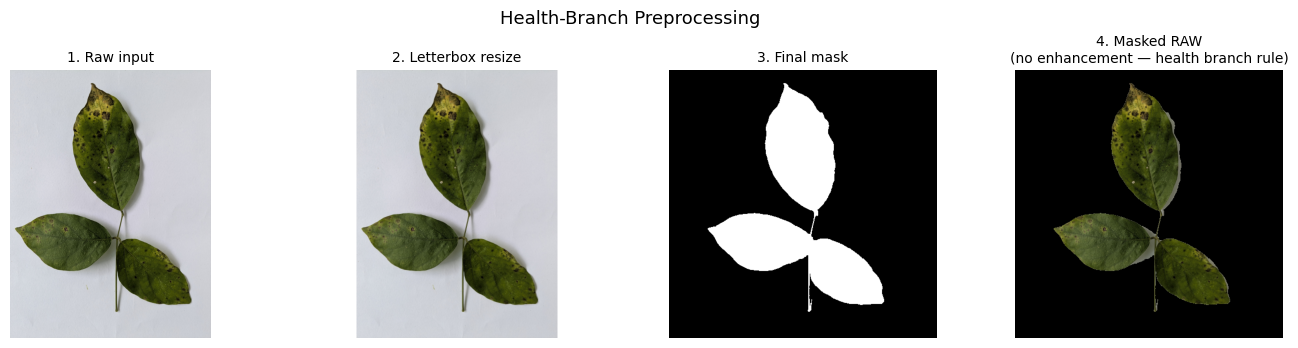

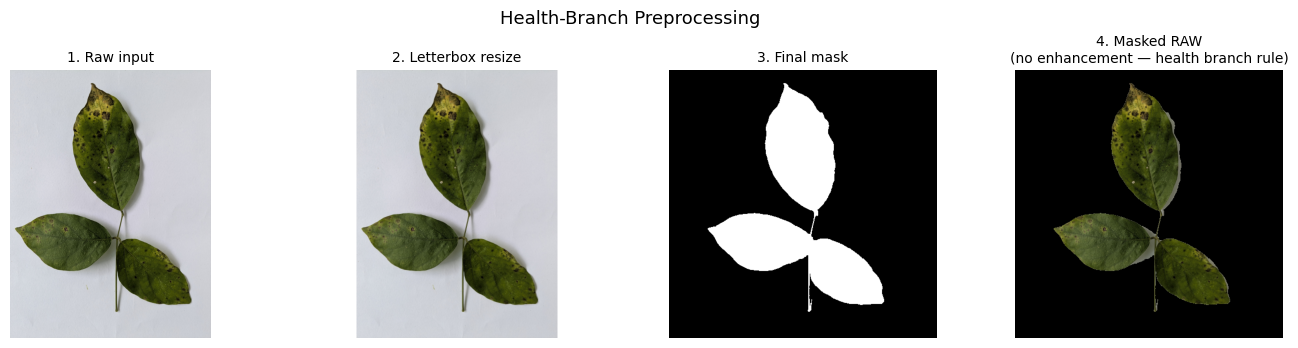

In [57]:
show_grid(
    [bgr2rgb(img_top_raw), bgr2rgb(h_top["resized"]), h_top["mask_final"], bgr2rgb(h_top["masked_raw"])],
    ["1. Raw input", "2. Letterbox resize", "3. Final mask", "4. Masked RAW\n(no enhancement — health branch rule)"],
    ncols=4, figsize_per=(3.5,3.5), suptitle="Health-Branch Preprocessing",
    save_as="B1_health_preprocessing",
)


### B.1b — Health-branch augmentation (geometry-only)

**Deliberately stricter than species-ID** — only flip + rotate, no
photometric transforms at all, since `colour_health.py`'s necrotic/
chlorotic/pale classification is the primary health signal and any
colour jitter risks fabricating a false severity shift. All four
targets (image, `mask_final`, `mask_before_holefill`, `rachis_mask`)
are warped through the identical transform.

[saved] figures_out\B1b_health_augmentation.png


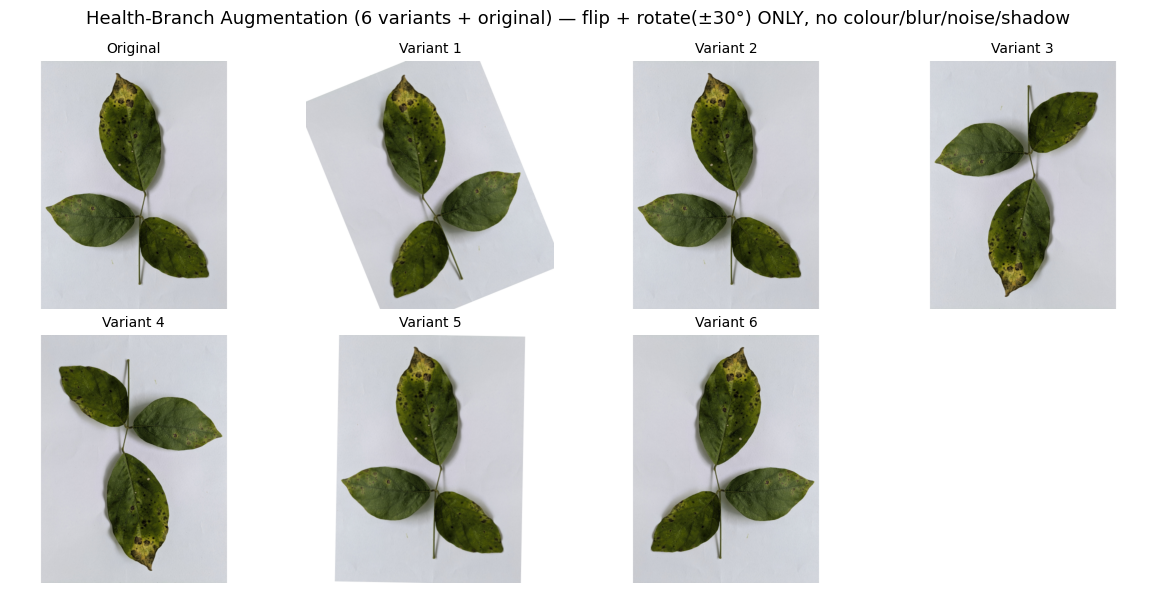

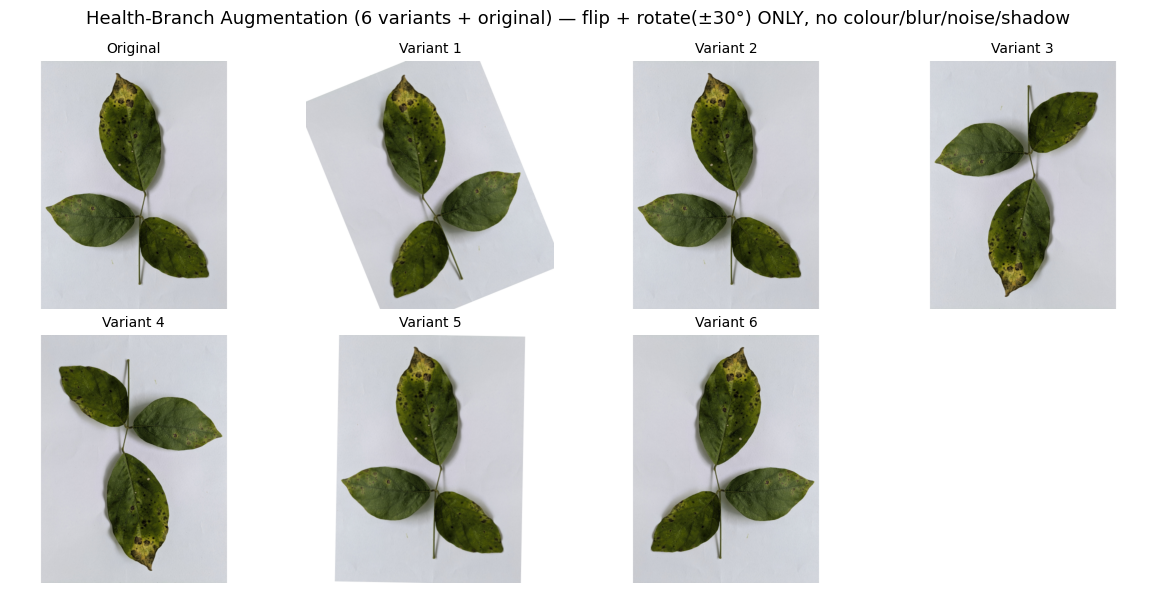

In [58]:
from preprocessing.shared.augmentation import augment_health_resized_with_masks_and_original

health_quads = augment_health_resized_with_masks_and_original(
    h_top["resized"], h_top["mask_final"], h_top["mask_before_holefill"], h_top["rachis_mask"],
    n=N_AUGMENTATIONS,
)
# each quad = (image, mask_final, mask_before_holefill, rachis_mask); quad[0] = original

show_grid(
    [bgr2rgb(img) for img, _, _, _ in health_quads],
    ["Original"] + [f"Variant {i+1}" for i in range(N_AUGMENTATIONS)],
    ncols=4, figsize_per=(3,3),
    suptitle=f"Health-Branch Augmentation ({N_AUGMENTATIONS} variants + original) — "
             f"flip + rotate(\u00b130\u00b0) ONLY, no colour/blur/noise/shadow",
    save_as="B1b_health_augmentation",
)


### B.2 — Boundary / margin damage

Margin deficit, contour roughness, and notch detection along the leaf silhouette.

[saved] figures_out\B2_boundary_margin_damage.png


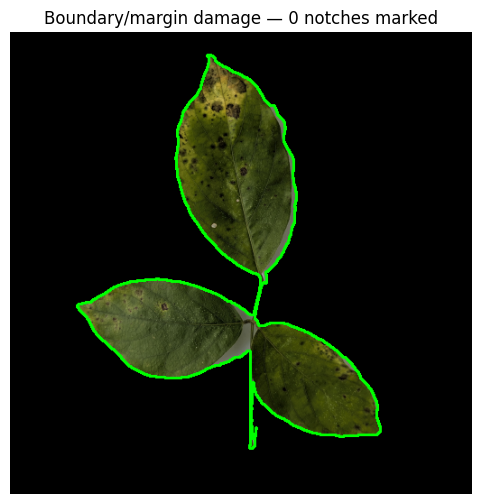

{'boundary_margin_deficit_ratio': 0.2037, 'boundary_contour_roughness': 1.1098, 'boundary_notch_count': 0, 'boundary_notch_density': 0.0, 'boundary_notch_depth_mean': 0.0}


In [59]:
from feature_extraction.health.boundary import extract_boundary_features, _largest_contour, _dilate_rachis

boundary_f = extract_boundary_features(h_top["mask_final"], rachis_mask=h_top["rachis_mask"])
contour = _largest_contour(h_top["mask_final"])
rachis_dilated = _dilate_rachis(h_top["rachis_mask"], proximity_px=15) if h_top["rachis_mask"] is not None else None

def notches_with_points(contour, rachis_dilated=None, min_depth_px=3.0):
    """Mirrors feature_extraction.health.boundary._notches()'s exact filtering
    logic, but also keeps each kept notch's (x,y) location for plotting —
    the real _notches() only returns (count, mean_depth), no coordinates."""
    if len(contour) < 5:
        return []
    hull_indices = cv2.convexHull(contour, returnPoints=False)
    if hull_indices is None or len(hull_indices) < 3:
        return []
    hull_indices = np.sort(hull_indices, axis=0)
    try:
        defects = cv2.convexityDefects(contour, hull_indices)
    except cv2.error:
        return []
    if defects is None:
        return []
    depths = defects[:, 0, 3] / 256.0
    far_idxs = defects[:, 0, 2]
    points = []
    for depth, far_idx in zip(depths, far_idxs):
        if depth < min_depth_px:
            continue
        fx, fy = contour[far_idx][0]
        if rachis_dilated is not None and 0 <= fy < rachis_dilated.shape[0] and 0 <= fx < rachis_dilated.shape[1]:
            if rachis_dilated[fy, fx]:
                continue
        points.append((int(fx), int(fy)))
    return points

notch_points = notches_with_points(contour, rachis_dilated=rachis_dilated)
assert len(notch_points) == boundary_f["boundary_notch_count"], (
    "sanity check: local reimplementation should match extract_boundary_features()'s "
    f"count exactly ({len(notch_points)} vs {boundary_f['boundary_notch_count']}) — "
    "if this fails, _notches()'s logic in boundary.py has diverged from this copy."
)

overlay = bgr2rgb(h_top["masked_raw"]).copy()
cv2.drawContours(overlay, [contour], -1, (0,255,0), 2)
for (fx, fy) in notch_points:
    cv2.circle(overlay, (fx, fy), 6, (255,0,0), -1)

fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(overlay); ax.set_title(f"Boundary/margin damage — {len(notch_points)} notches marked"); ax.axis("off")
save_fig(fig, "B2_boundary_margin_damage")
plt.show()
print({k: round(v,4) if isinstance(v,float) else v for k,v in boundary_f.items()})


### B.3 — Hole / puncture detection

`filled_in = mask_final AND NOT mask_before_holefill` — the exact logic `holes.py` uses.

[saved] figures_out\B3_hole_detection.png


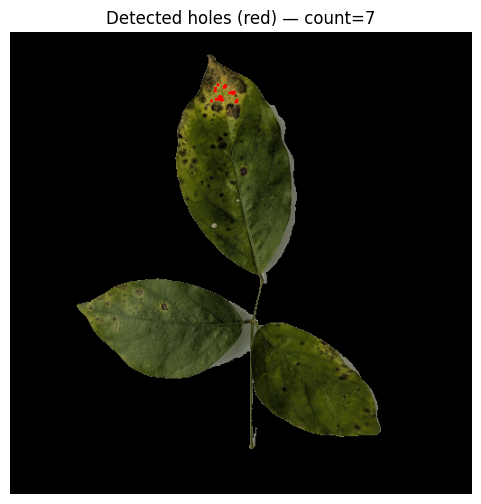

{'hole_count': 7, 'hole_area_ratio': 0.0029871278372801415, 'hole_mean_size': 21.714285714285715}


In [60]:
from feature_extraction.health.holes import extract_hole_features

hole_f = extract_hole_features(h_top["mask_final"], h_top["mask_before_holefill"])

overlay = bgr2rgb(h_top["masked_raw"]).copy()
if h_top["mask_before_holefill"] is not None:
    filled_in = cv2.bitwise_and(h_top["mask_final"].astype(np.uint8),
                                 cv2.bitwise_not(h_top["mask_before_holefill"].astype(np.uint8)))
    overlay[filled_in > 0] = [255, 0, 0]

fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(overlay); ax.set_title(f"Detected holes (red) — count={hole_f['hole_count']}"); ax.axis("off")
save_fig(fig, "B3_hole_detection")
plt.show()
print(hole_f)


### B.4 — Colour & discolouration

Necrotic / chlorotic / pale-patch classification masks (calls `colour_health.py`'s internal `_classify_damage_masks` directly for the overlay).

[saved] figures_out\B4_colour_discolouration.png


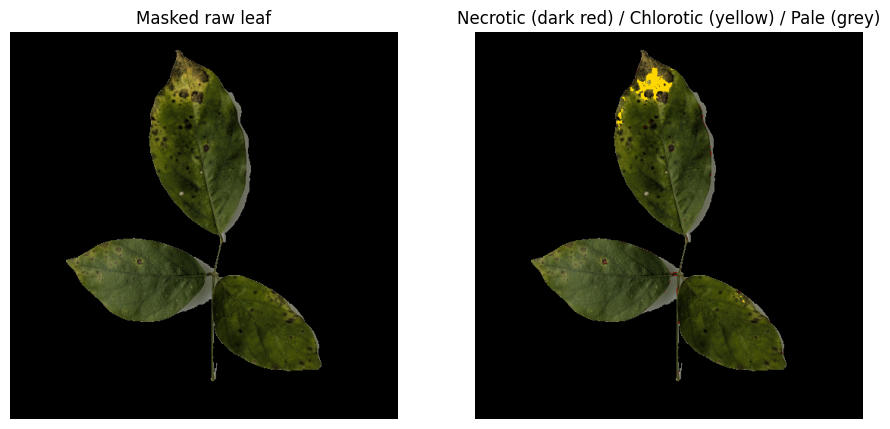

{'colour_pct_necrotic': 0.1808, 'colour_pct_chlorotic': 1.8571, 'colour_pct_pale_patch': 0.0079, 'colour_pct_healthy_green': 97.9542, 'colour_lab_a_median': 116.0, 'colour_lab_a_iqr': 4.0, 'colour_lab_b_median': 153.0, 'colour_lab_b_iqr': 10.0}


In [61]:
from feature_extraction.health.colour_health import extract_colour_health_features, _classify_damage_masks

colour_h_f = extract_colour_health_features(h_top["masked_raw"], h_top["mask_final"])
damage_masks = _classify_damage_masks(h_top["masked_raw"], h_top["mask_final"])

overlay = bgr2rgb(h_top["masked_raw"]).copy()
if "necrotic" in damage_masks: overlay[damage_masks["necrotic"] > 0] = [139, 0, 0]     # dark red
if "chlorotic" in damage_masks: overlay[damage_masks["chlorotic"] > 0] = [255, 215, 0]  # yellow
if "pale" in damage_masks: overlay[damage_masks["pale"] > 0] = [200, 200, 200]  # pale grey

fig, ax = plt.subplots(1,2, figsize=(11,5.5))
ax[0].imshow(bgr2rgb(h_top["masked_raw"])); ax[0].set_title("Masked raw leaf"); ax[0].axis("off")
ax[1].imshow(overlay); ax[1].set_title("Necrotic (dark red) / Chlorotic (yellow) / Pale (grey)"); ax[1].axis("off")
save_fig(fig, "B4_colour_discolouration")
plt.show()
print({k: round(v,4) if isinstance(v,float) else v for k,v in colour_h_f.items()})


### B.5 — Scar tissue detection

[saved] figures_out\B5_scar_detection.png


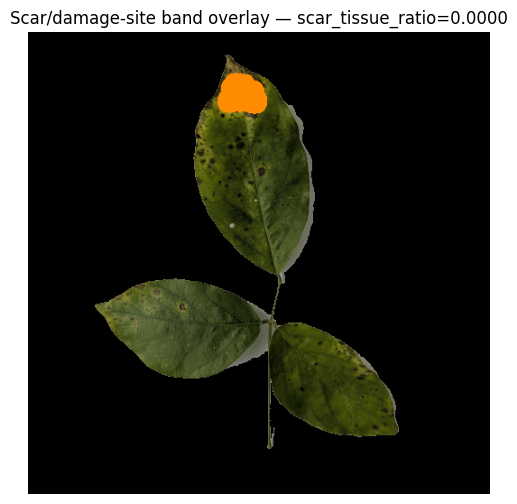

{'scar_tissue_ratio': 0.0}


In [62]:
from feature_extraction.health.scar import extract_scar_features, _damage_site_mask

scar_f = extract_scar_features(h_top["masked_raw"], h_top["mask_final"],
                                mask_before_holefill=h_top["mask_before_holefill"],
                                rachis_mask=h_top["rachis_mask"])

# _damage_site_mask(mask_final, mask_before_holefill, rachis_mask=None, ...) -> np.ndarray
scar_mask = _damage_site_mask(h_top["mask_final"], h_top["mask_before_holefill"],
                               rachis_mask=h_top["rachis_mask"])
overlay = bgr2rgb(h_top["masked_raw"]).copy()
overlay[scar_mask > 0] = [255, 140, 0]

fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(overlay); ax.set_title(f"Scar/damage-site band overlay — scar_tissue_ratio={scar_f.get('scar_tissue_ratio', 0):.4f}")
ax.axis("off")
save_fig(fig, "B5_scar_detection")
plt.show()
print(scar_f)


### B.6 — Leaf-miner trail detection

[saved] figures_out\B6_miner_trail.png


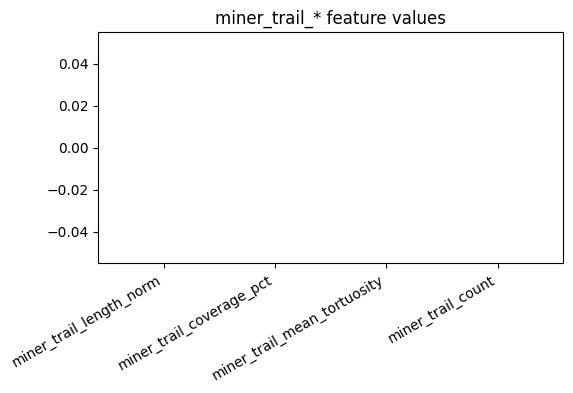

{'miner_trail_length_norm': 0.0, 'miner_trail_coverage_pct': 0.0, 'miner_trail_mean_tortuosity': 0.0, 'miner_trail_count': 0}


In [63]:
from feature_extraction.health.miner_trail import extract_miner_trail_features

miner_f = extract_miner_trail_features(h_top["masked_raw"], h_top["mask_final"])

fig, ax = plt.subplots(figsize=(6,3))
keys = [k for k in miner_f if isinstance(miner_f[k], (int,float))]
ax.bar(keys, [miner_f[k] for k in keys], color="darkgoldenrod")
ax.set_title("miner_trail_* feature values")
plt.xticks(rotation=30, ha="right")
save_fig(fig, "B6_miner_trail")
plt.show()
print(miner_f)


### B.7 — Texture disruption (GLCM + LBP on masked raw)

[saved] figures_out\B7_texture_disruption.png


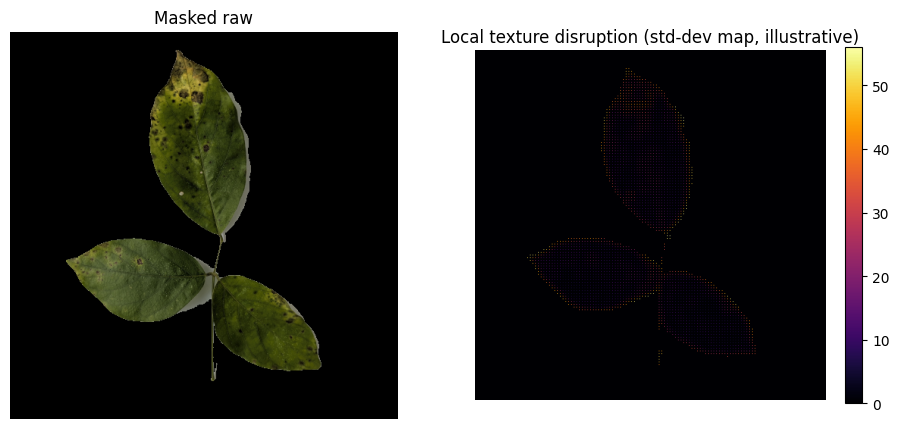

{'texture_h_glcm_contrast_mean': 5.700430821189542, 'texture_h_glcm_contrast_std': 1.6643575773914578, 'texture_h_glcm_homogeneity_mean': 0.7879978039573561, 'texture_h_glcm_homogeneity_std': 0.02318418531161283, 'texture_h_glcm_energy_mean': 0.6652860020122771, 'texture_h_glcm_energy_std': 0.006484739110630045, 'texture_h_glcm_correlation_mean': 0.7274535439216141, 'texture_h_glcm_correlation_std': 0.07900447773983016, 'texture_h_lbp_uniformity': 0.520742851527945, 'texture_h_lbp_entropy': 3.105924410424156}


In [64]:
from feature_extraction.health.texture_health import extract_texture_health_features
from skimage.feature import graycomatrix, graycoprops

texture_h_f = extract_texture_health_features(h_top["masked_raw"], h_top["mask_final"])

gray = cv2.cvtColor(h_top["masked_raw"], cv2.COLOR_BGR2GRAY)
# simple sliding-window local contrast map for illustration
win = 15
pad = win // 2
padded = np.pad(gray, pad, mode="reflect")
contrast_map = np.zeros_like(gray, dtype=np.float32)
for y in range(0, gray.shape[0], 4):        # stride 4 for speed
    for x in range(0, gray.shape[1], 4):
        if h_top["mask_final"][y, x] == 0:
            continue
        patch = padded[y:y+win, x:x+win]
        contrast_map[y, x] = patch.std()

fig, ax = plt.subplots(1,2, figsize=(11,5.5))
ax[0].imshow(bgr2rgb(h_top["masked_raw"])); ax[0].set_title("Masked raw"); ax[0].axis("off")
im = ax[1].imshow(contrast_map, cmap="inferno")
ax[1].set_title("Local texture disruption (std-dev map, illustrative)"); ax[1].axis("off")
fig.colorbar(im, ax=ax[1], fraction=0.046)
save_fig(fig, "B7_texture_disruption")
plt.show()
print(texture_h_f)


### B.8 — Deformation (specular highlights + width-profile roughness)

[saved] figures_out\B8_deformation.png


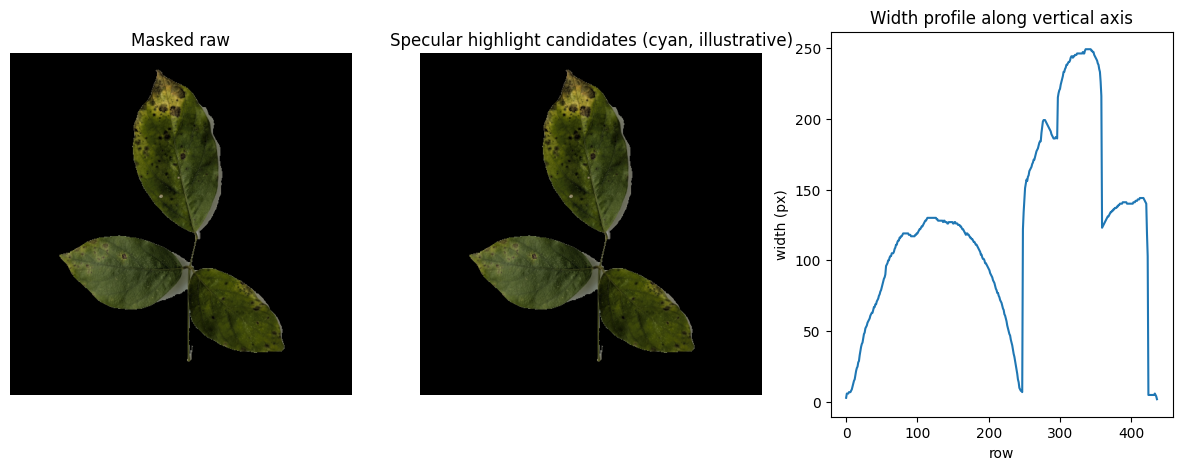

{'deform_specular_pct': 0.0, 'deform_specular_blob_density': 0.0, 'deform_width_profile_roughness': 0.1482537707787881, 'deform_luminance_std': 27.391603469848633}


In [65]:
from feature_extraction.health.deformation import extract_deformation_features

deform_f = extract_deformation_features(h_top["masked_raw"], h_top["mask_final"], rachis_mask=h_top["rachis_mask"])

# specular highlight overlay (bright, low-saturation pixels within the mask)
hsv = cv2.cvtColor(h_top["masked_raw"], cv2.COLOR_BGR2HSV)
specular_candidate = (hsv[...,2] > 230) & (hsv[...,1] < 40) & (h_top["mask_final"] > 0)
overlay = bgr2rgb(h_top["masked_raw"]).copy()
overlay[specular_candidate] = [0, 255, 255]

# width profile along vertical axis (simple illustrative version)
ys, xs = np.where(h_top["mask_final"] > 0)
widths = [xs[ys==y].max()-xs[ys==y].min() if np.any(ys==y) else 0 for y in range(h_top["mask_final"].shape[0])]

fig, ax = plt.subplots(1,3, figsize=(15,5))
ax[0].imshow(bgr2rgb(h_top["masked_raw"])); ax[0].set_title("Masked raw"); ax[0].axis("off")
ax[1].imshow(overlay); ax[1].set_title("Specular highlight candidates (cyan, illustrative)"); ax[1].axis("off")
ax[2].plot([w for w in widths if w>0]); ax[2].set_title("Width profile along vertical axis")
ax[2].set_xlabel("row"); ax[2].set_ylabel("width (px)")
save_fig(fig, "B8_deformation")
plt.show()
print(deform_f)


### B.9 — Spot / lesion detection

[saved] figures_out\B9_spot_lesion_detection.png


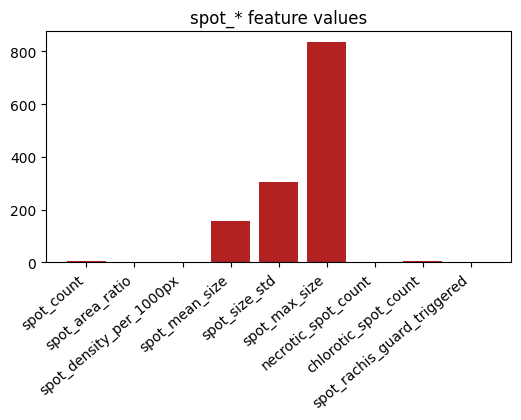

{'spot_count': 6, 'spot_area_ratio': 0.018296158003340866, 'spot_density_per_1000px': 0.11791294094526875, 'spot_mean_size': 155.16666666666666, 'spot_size_std': 303.74244389321393, 'spot_max_size': 834, 'necrotic_spot_count': 1, 'chlorotic_spot_count': 5, 'spot_rachis_guard_triggered': True}


In [66]:
from feature_extraction.health.spots import extract_spot_features

spot_f = extract_spot_features(h_top["masked_raw"], h_top["mask_final"], rachis_mask=h_top["rachis_mask"])

fig, ax = plt.subplots(figsize=(6,3))
keys = [k for k in spot_f if isinstance(spot_f[k], (int,float))]
ax.bar(keys, [spot_f[k] for k in keys], color="firebrick")
ax.set_title("spot_* feature values")
plt.xticks(rotation=40, ha="right")
save_fig(fig, "B9_spot_lesion_detection")
plt.show()
print(spot_f)
# NOTE: this cell reports numeric spot_* values only. A precise pixel-level
# blob overlay would need spots.py's internal candidate-mask construction
# (_build_exclusion_mask + blob threshold) exposed as a debug return —
# flag this as a possible extension if a literal "spots circled on the
# leaf" figure (like the interim report's) is required.


### B.10 — LDSI sub-scores (rule-based composite, feature-extraction time)

[saved] figures_out\B10_ldsi_subscores.png


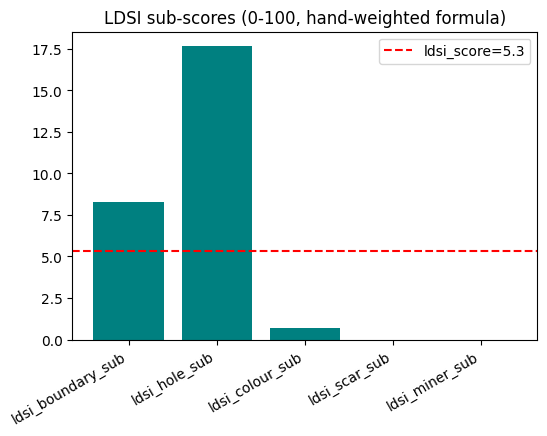

{'ldsi_boundary_sub': 8.253322142192589, 'ldsi_hole_sub': 17.649356391864007, 'ldsi_colour_sub': 0.6819298418001375, 'ldsi_scar_sub': 0.0, 'ldsi_miner_sub': 0.0, 'ldsi_score': 5.316921675171347}


In [67]:
from feature_extraction.health.severity_index import compute_ldsi

ldsi_f = compute_ldsi(boundary_f, hole_f, colour_h_f, scar_f, miner_feats=miner_f)

fig, ax = plt.subplots(figsize=(6,4))
subs = {k:v for k,v in ldsi_f.items() if k != "ldsi_score"}
ax.bar(subs.keys(), subs.values(), color="teal")
ax.axhline(ldsi_f["ldsi_score"], color="red", linestyle="--", label=f"ldsi_score={ldsi_f['ldsi_score']:.1f}")
ax.set_title("LDSI sub-scores (0-100, hand-weighted formula)")
ax.legend()
plt.xticks(rotation=30, ha="right")
save_fig(fig, "B10_ldsi_subscores")
plt.show()
print(ldsi_f)

# Bundle every group computed above into one per-view row, with the
# "species" key assess_leaf() reads from (see predict_health.py:97).
top_row_full = {}
for d in (boundary_f, hole_f, colour_h_f, scar_f, miner_f, texture_h_f, deform_f, spot_f, ldsi_f):
    top_row_full.update(d)
top_row_full["species"] = SPECIES_NAME


### B.10b — Compute the same features for the bottom view

`assess_leaf()` fuses genuine top/bottom rows (worst-side-wins per
feature) — it needs BOTH views actually run through the 9 feature
modules, not the top row duplicated. If no bottom image was supplied,
this falls back to reusing the top row (equivalent to `top==bottom`,
i.e. `worst_* == top_*` everywhere) and says so explicitly.

In [68]:
def compute_all_health_features(h, species_name):
    """Run all 9 feature-extraction modules on one preprocessed view (h_top or h_bottom)."""
    b_f = extract_boundary_features(h["mask_final"], rachis_mask=h["rachis_mask"])
    ho_f = extract_hole_features(h["mask_final"], h["mask_before_holefill"])
    c_f = extract_colour_health_features(h["masked_raw"], h["mask_final"])
    s_f = extract_scar_features(h["masked_raw"], h["mask_final"],
                                 mask_before_holefill=h["mask_before_holefill"],
                                 rachis_mask=h["rachis_mask"])
    m_f = extract_miner_trail_features(h["masked_raw"], h["mask_final"])
    t_f = extract_texture_health_features(h["masked_raw"], h["mask_final"])
    d_f = extract_deformation_features(h["masked_raw"], h["mask_final"], rachis_mask=h["rachis_mask"])
    sp_f = extract_spot_features(h["masked_raw"], h["mask_final"],
                                  mask_before_holefill=h["mask_before_holefill"],
                                  rachis_mask=h["rachis_mask"])
    l_f = compute_ldsi(b_f, ho_f, c_f, s_f, miner_feats=m_f)
    row = {}
    for d in (b_f, ho_f, c_f, s_f, m_f, t_f, d_f, sp_f, l_f):
        row.update(d)
    row["species"] = species_name
    return row

if h_bottom is not None:
    bottom_row_full = compute_all_health_features(h_bottom, SPECIES_NAME)
else:
    print("[note] no bottom image supplied — reusing top_row_full as bottom_row "
          "(worst_* will equal top_* for every feature; not a real fused assessment).")
    bottom_row_full = dict(top_row_full)


### B.11 & B.12 — Full assessment: Health Index + Stage 1, via `assess_leaf()`

One call does the real fuse-then-score pipeline correctly (species
column, per-species Health Index scaling, Stage-1 z-features, both
models fed from the same fused row) — see `predict_health.py::assess_leaf`.


{'species': 'wal_kollu', 'decision': 'unhealthy', 'decision_confidence': 1.0, 'health_value': 20.12, 'severity_score_raw': 79.88, 'breakdown': {'worst_ldsi_boundary_sub': 37.8, 'worst_colour_pct_chlorotic': 0.0, 'worst_colour_pct_pale_patch': 0.1, 'worst_ldsi_miner_sub': 0.0, 'worst_hole_count': 44.8, 'worst_texture_h_glcm_contrast_mean': 0.0, 'worst_texture_h_lbp_entropy': 4.4, 'worst_deform_luminance_std': 0.0, 'worst_spot_count': 10.6, 'worst_spot_area_ratio': 0.0, 'worst_spot_density_per_1000px': 2.3}}
[saved] figures_out\B11_health_index_breakdown.png


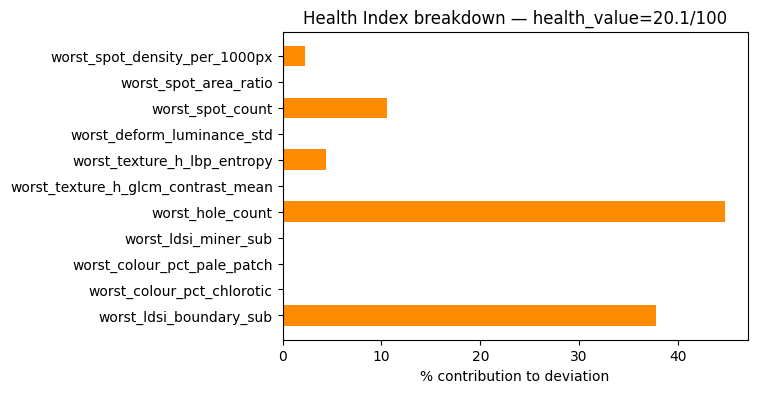

[saved] figures_out\B12_stage1_decision.png


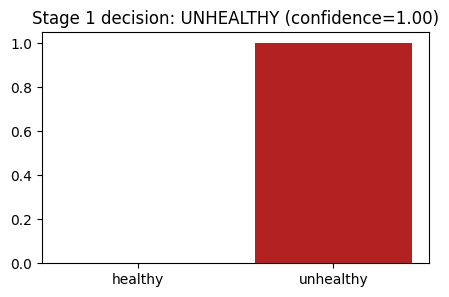

In [69]:
from models.health.predict_health import assess_leaf

try:
    result = assess_leaf(top_row_full, bottom_row_full)
    print(result)

    # --- B.11: Health Index breakdown ---
    fig, ax = plt.subplots(figsize=(6,4))
    breakdown = result["breakdown"]
    ax.barh(list(breakdown.keys()), list(breakdown.values()), color="darkorange")
    ax.set_title(f"Health Index breakdown — health_value={result['health_value']:.1f}/100")
    ax.set_xlabel("% contribution to deviation")
    save_fig(fig, "B11_health_index_breakdown")
    plt.show()

    # --- B.12: Stage 1 decision ---
    fig, ax = plt.subplots(figsize=(5,3))
    conf = result["decision_confidence"]
    bars = [1-conf, conf] if result["decision"] == "unhealthy" else [conf, 1-conf]
    ax.bar(["healthy", "unhealthy"], bars, color=["seagreen", "firebrick"])
    ax.set_title(f"Stage 1 decision: {result['decision'].upper()} (confidence={conf:.2f})")
    save_fig(fig, "B12_stage1_decision")
    plt.show()
except FileNotFoundError as e:
    print(f"[skip] model file not found ({e}) — train Stage 1 (train_stage1_binary.py) "
          f"and the Health Index (train_health_index.py) first.")


---
## Summary

All figures were written to `figures_out/` — pull these directly into
Chapter 6 in place of hand-drawn illustrations. Sections **A** (species-ID)
and **B.1–B.4, B.10–B.12** use exact pipeline logic end-to-end; **B.7–B.9**
use simplified, clearly-labelled illustrative overlays where the source
modules don't already expose a debug mask — extend those modules to
return their internal candidate masks if pixel-perfect overlays are
needed for the final submission.
